In [2]:
import anndata
import os
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

## 整体数据测评

#### 查看数据情况

In [4]:
ad = anndata.read_h5ad("/data2/xiaoxinyu/project/embedding-cosine/DLPFC/top2000/151674/stdata.h5ad")
print(ad)

AnnData object with n_obs × n_vars = 3673 × 20000
    obs: 'in_tissue', 'array_row', 'array_col'
    obsm: 'spatial'


In [9]:
ad = anndata.read_h5ad("/data1/xiaoxinyu/benchmark/HK/process-data/redehist-data/st_data.h5ad")
print(ad)
# print(ad.var['feature_types'].unique())
# print(ad.var['feature_types'].value_counts()) 

AnnData object with n_obs × n_vars = 5936 × 18085
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


In [10]:
ad =anndata.read_h5ad("/data1/xiaoxinyu/data/redehist/example_data/st_data.HBC_visium.h5ad")
print(ad)

AnnData object with n_obs × n_vars = 4992 × 18085
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


/home/xiaoxinyu/miniconda3/envs/redehist/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


#### 添加注释信息

In [ ]:
import anndata
import pandas as pd

# 读取 AnnData
ad = anndata.read_h5ad("/data2/xiaoxinyu/project/embedding-cosine/DLPFC/top2000/151674/stdata.h5ad")

# 读取注释文件（设定分隔符为 tab，且没有表头）
df = pd.read_csv("/data2/xiaoxinyu/project/embedding-cosine/DLPFC/top2000/151674/151674_truth.txt",
                 sep="\t", header=None, names=["barcode", "layer"])

# 设置索引为 barcode，以便与 AnnData.obs 对齐
df.set_index("barcode", inplace=True)

# 确保只选取在 AnnData 中存在的条目
df_filtered = df.loc[df.index.intersection(ad.obs_names)]

# 添加到 AnnData.obs 中
ad.obs["layer"] = df_filtered["layer"]

# 检查缺失情况
missing = ad.obs["layer"].isna().sum()
print(f"添加完成，缺失注释的条目数: {missing}")

# 如需保存新的 AnnData 文件
ad.write_h5ad("/data2/xiaoxinyu/project/embedding-cosine/DLPFC/top2000/151674/stdata_with_layer.h5ad")


#### 按注释信息对文件拆分

In [21]:
ad = anndata.read_h5ad("/data2/xiaoxinyu/project/embedding-cosine/DLPFC/top2000/151674/stdata_with_layer.h5ad")
print(ad)
print(ad.obs['layer'].unique()) 
# print(ad.obs['layer'].value_counts()) 

AnnData object with n_obs × n_vars = 3673 × 20000
    obs: 'in_tissue', 'array_row', 'array_col', 'layer'
    obsm: 'spatial'
['Layer_3', 'Layer_1', 'WM', 'Layer_5', 'Layer_6', 'Layer_2', 'Layer_4', NaN]
Categories (7, object): ['Layer_1', 'Layer_2', 'Layer_3', 'Layer_4', 'Layer_5', 'Layer_6', 'WM']


In [ ]:
import anndata
import os

# 读取原始 AnnData 对象
ad = anndata.read_h5ad("/data2/xiaoxinyu/project/embedding-cosine/DLPFC/top2000/151674/stdata_with_layer.h5ad")

# 输出文件夹路径
output_dir = "/data2/xiaoxinyu/project/embedding-cosine/DLPFC/top2000/151674/layer"
os.makedirs(output_dir, exist_ok=True)

# 获取所有注释类型
cell_types = ad.obs['layer'].unique()

# 遍历每个注释类型，子集并保存为新的 .h5ad 文件
for cell_type in cell_types:
    ad_subset = ad[ad.obs['layer'] == cell_type].copy()
    filename = f"{cell_type.replace(' ', '_')}.h5ad"
    file_path = os.path.join(output_dir, filename)
    ad_subset.write_h5ad(file_path)
    print(f"Saved {cell_type} ({ad_subset.n_obs} cells) to {file_path}")

#### 获取前20000个基因

In [10]:
# work_dir = "/data1/xiaoxinyu/benchmark/DLPFC/process-data/train-data"
import anndata
import numpy as np

# 加载原始 h5ad
adata = anndata.read_h5ad("/data1/xiaoxinyu/benchmark/DLPFC/process-data/val-data/151507/st_data.h5ad")

# 计算每个基因的总表达量（所有 spot 上求和）
gene_sum = np.array(adata.X.sum(axis=0)).flatten()

# 获取前 20,000 个表达量最大的基因索引
top_k = 20000
top_gene_indices = np.argsort(gene_sum)[-top_k:]

# 筛选这些基因对应的列（axis=1）
adata_top = adata[:, top_gene_indices]

# 保存为新 h5ad（可选）
adata_top.write_h5ad("/data2/xiaoxinyu/project/embedding-cosine/DLPFC/top2000/151507/st_data.h5ad")


#### 获取同一数据不同spot的嵌入

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import subprocess

# 读取数据
truedata = sc.read_h5ad("/data2/xiaoxinyu/project/embedding-cosine/DLPFC/top2000/151674/stdata.h5ad")

# 第一行
first_row = truedata[1500:2000, :].copy()  
first_row.write("/data2/xiaoxinyu/project/embedding-cosine/DLPFC/top2000/151674/stdata1520.h5ad")

h5ad_path = "/data2/xiaoxinyu/project/embedding-cosine/DLPFC/top2000/151674/stdata1520.h5ad"

gene_out = "/data2/xiaoxinyu/project/embedding-cosine/DLPFC/embedding/151674/stdata1520.pt"

subprocess.run([
            "conda", "run", "-n", "nicheformer",
            "python", "/data2/xiaoxinyu/project/gene-embedding.py",
            "--input", h5ad_path,
            "--output", gene_out
        ], check=True)


Using provided technology mean array with shape (20310,)
✅ Embedding saved to: /data2/xiaoxinyu/project/embedding-cosine/DLPFC/embedding/151674/stdata1520.pt



CompletedProcess(args=['conda', 'run', '-n', 'nicheformer', 'python', '/data2/xiaoxinyu/project/gene-embedding.py', '--input', '/data2/xiaoxinyu/project/embedding-cosine/DLPFC/top2000/151674/stdata1520.h5ad', '--output', '/data2/xiaoxinyu/project/embedding-cosine/DLPFC/embedding/151674/stdata1520.pt'], returncode=0)

#### 分批获取完整嵌入

In [ ]:
import os
import torch
import subprocess
import scanpy as sc
from tqdm import tqdm

# 路径配置
# h5ad_path = "/data2/xiaoxinyu/project/embedding-cosine/DLPFC/top2000/151674/stdata.h5ad"
# output_dir = "/data2/xiaoxinyu/project/embedding-cosine/DLPFC/embedding/151674/split_tmp"
# final_out = "/data2/xiaoxinyu/project/embedding-cosine/DLPFC/embedding/151674/stdata.pt"

# 路径配置
h5ad_path = "/data2/xiaoxinyu/project/embedding-cosine/HBC/sc/B_cells.h5ad"
output_dir = "/data2/xiaoxinyu/project/embedding-cosine/HBC/sc/split_tmp"
final_out = "/data2/xiaoxinyu/project/embedding-cosine/HBC/sc-B_cells.pt"


# 参数配置
batch_size = 500
env_name = "nicheformer"
embedding_script = "/data2/xiaoxinyu/project/gene-embedding.py"

# 创建临时输出目录
os.makedirs(output_dir, exist_ok=True)

# 读取原始数据
ad = sc.read_h5ad(h5ad_path)
total = ad.shape[0]

# 存储每个 batch 的 embedding 路径
embedding_list = []

for i in tqdm(range(0, total, batch_size)):
    end = min(i + batch_size, total)
    sub_ad = ad[i:end].copy()
    
    sub_h5ad_path = os.path.join(output_dir, f"sub_{i}_{end}.h5ad")
    sub_out_path = os.path.join(output_dir, f"sub_{i}_{end}.pt")

    # 保存子 h5ad 文件
    sub_ad.write(sub_h5ad_path)

    # 执行子进程运行 embedding
    subprocess.run([
        "conda", "run", "-n", env_name,
        "python", embedding_script,
        "--input", sub_h5ad_path,
        "--output", sub_out_path
    ], check=True)

    embedding_list.append(sub_out_path)

# 合并所有子嵌入
all_embeddings = []
for pt_path in embedding_list:
    emb = torch.load(pt_path)
    all_embeddings.append(emb)

final_embedding = torch.cat(all_embeddings, dim=0)
torch.save(final_embedding, final_out)

print(f"✅ Final embedding saved to: {final_out}")


 14%|█▍        | 1/7 [00:55<05:33, 55.61s/it]

Using provided technology mean array with shape (20310,)
✅ Embedding saved to: /data2/xiaoxinyu/project/embedding-cosine/HBC/sc/split_tmp/sub_0_500.pt



 29%|██▊       | 2/7 [01:51<04:38, 55.77s/it]

Using provided technology mean array with shape (20310,)
✅ Embedding saved to: /data2/xiaoxinyu/project/embedding-cosine/HBC/sc/split_tmp/sub_500_1000.pt



 43%|████▎     | 3/7 [02:46<03:42, 55.59s/it]

...

Using provided technology mean array with shape (20310,)
✅ Embedding saved to: /data2/xiaoxinyu/project/embedding-cosine/HBC/sc/split_tmp/sub_2000_2500.pt



 86%|████████▌ | 6/7 [05:33<00:55, 55.60s/it]

Using provided technology mean array with shape (20310,)
✅ Embedding saved to: /data2/xiaoxinyu/project/embedding-cosine/HBC/sc/split_tmp/sub_2500_3000.pt



100%|██████████| 7/7 [06:06<00:00, 52.34s/it]

Using provided technology mean array with shape (20310,)
✅ Embedding saved to: /data2/xiaoxinyu/project/embedding-cosine/HBC/sc/split_tmp/sub_3000_3244.pt

✅ Final embedding saved to: /data2/xiaoxinyu/project/embedding-cosine/HBC/sc-DCIS.pt


#### 输入文件嵌入

##### 相同行数

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# 加载 embedding
emb_actg1 = torch.load('/data2/xiaoxinyu/project/embedding-cosine/DLPFC/embedding/151674/layer-ft/Layer_3_gene.pt')
emb_actb = torch.load('/data2/xiaoxinyu/project/embedding-cosine/DLPFC/embedding/151674/layer-raw/Layer_3.pt')

# 转为 numpy
vec1 = emb_actg1.detach().numpy().reshape(1, -1)
vec2 = emb_actb.detach().numpy().reshape(1, -1)

# 计算余弦相似度
sim = cosine_similarity(vec1, vec2)[0][0]
print(f"余弦相似度: {sim:.4f}")


余弦相似度: 0.2897


##### 不同行数

In [42]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

emb_actg1 = torch.load('/data2/xiaoxinyu/project/embedding-cosine/DLPFC/embedding/151674/layer-raw/Layer_1_gene.pt')
emb_actb = torch.load('/data2/xiaoxinyu/project/embedding-cosine/DLPFC/embedding/151674/layer-raw/Layer_1.pt')
# emb_hbc = torch.load('/data2/xiaoxinyu/project/embedding-cosine/HBC/stdata.pt')


In [43]:
vec1_mean = emb_actg1.mean(dim=0, keepdim=True).detach().numpy()
vec2_mean = emb_actb.mean(dim=0, keepdim=True).detach().numpy()

sim = cosine_similarity(vec1_mean, vec2_mean)[0][0]
print(f"平均向量的余弦相似度: {sim:.4f}")

平均向量的余弦相似度: 1.0000


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
emb_all = torch.cat([emb_actg1, emb_actb], dim=0).detach().numpy()
emb_pca = pca.fit_transform(emb_all)

emb1_pca = emb_pca[:emb_actg1.shape[0]]
emb2_pca = emb_pca[emb_actg1.shape[0]:]

sim = cosine_similarity(emb1_pca.mean(axis=0).reshape(1, -1), emb2_pca.mean(axis=0).reshape(1, -1))[0][0]
print(f"PCA降维后均值向量的余弦相似度: {sim:.4f}")


PCA降维后均值向量的余弦相似度: -1.0000


/home/xiaoxinyu/miniconda3/envs/redehist/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


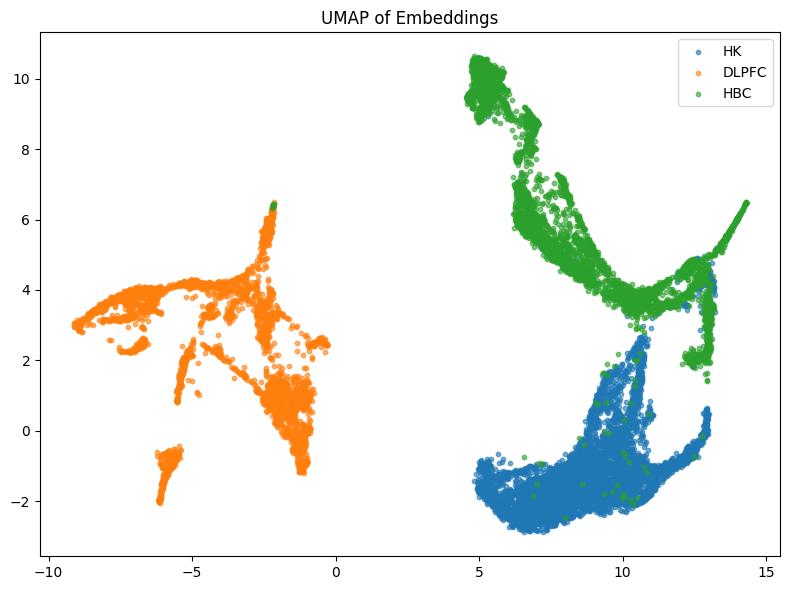

In [112]:
# 可视化
import umap
import matplotlib.pyplot as plt

# 转为 numpy
emb1 = emb_actg1.detach().numpy()
emb2 = emb_actb.detach().numpy()
emb3 = emb_hbc.detach().numpy()

# 合并数据
X = np.vstack([emb1, emb2, emb3])
labels = np.array([0]*len(emb1) + [1]*len(emb2) + [2]*len(emb3))  # 0: HK, 1: DLPFC, 2: HBC

# UMAP降维
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)

# 可视化
plt.figure(figsize=(8, 6))
plt.scatter(X_umap[labels==0, 0], X_umap[labels==0, 1], s=10, alpha=0.6, label="HK")
plt.scatter(X_umap[labels==1, 0], X_umap[labels==1, 1], s=10, alpha=0.6, label="DLPFC")
plt.scatter(X_umap[labels==2, 0], X_umap[labels==2, 1], s=10, alpha=0.6, label="HBC")
plt.title("UMAP of Embeddings")
plt.legend()
plt.tight_layout()
plt.show()


#### 输入文件夹嵌入

/home/xiaoxinyu/miniconda3/envs/redehist/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


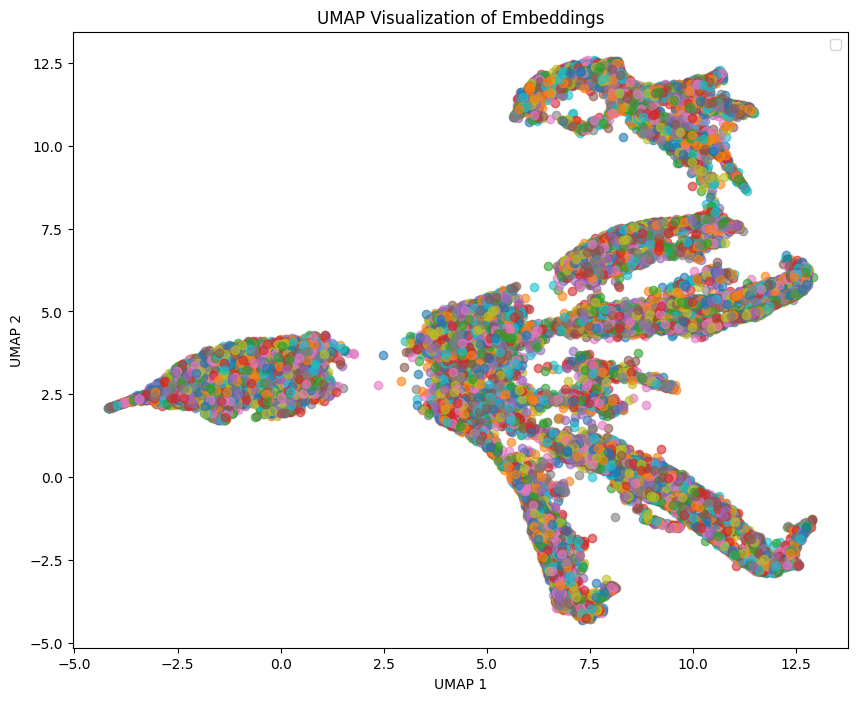

In [1]:
import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import umap
import matplotlib.pyplot as plt
import os

# 1. 加载所有pt文件
folder_path = "/data2/xiaoxinyu/project/gene_text_pairs/DLPFC/gene-embeddings"
pt_files = [f for f in os.listdir(folder_path) if f.endswith('.pt')]
embeddings = [torch.load(os.path.join(folder_path, f)) for f in pt_files]

# # 2. 计算两两余弦相似度(需要行数相同)
# similarity_matrix = np.zeros((len(embeddings), len(embeddings)))
# for i in range(len(embeddings)):
#     for j in range(len(embeddings)):
#         # 将张量转换为numpy数组并展平
#         vec1 = embeddings[i].detach().numpy().reshape(1, -1)
#         vec2 = embeddings[j].detach().numpy().reshape(1, -1)
#         similarity_matrix[i,j] = cosine_similarity(vec1, vec2)[0][0]
#
# print("余弦相似度矩阵:")
# print(similarity_matrix)

# 3. UMAP降维可视化
# 合并所有嵌入
all_embeddings = torch.cat(embeddings, dim=0).detach().numpy()

# 执行UMAP降维
reducer = umap.UMAP()
# reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=42)

embedding_2d = reducer.fit_transform(all_embeddings)

# 可视化
plt.figure(figsize=(10, 8))
for i, file in enumerate(pt_files):
    start = i * len(embeddings[0])
    end = start + len(embeddings[0])
    plt.scatter(embedding_2d[start:end, 0], 
                embedding_2d[start:end, 1], 
                # label=file, 
                alpha=0.6)

plt.title('UMAP Visualization of Embeddings')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend()
plt.savefig(os.path.join(folder_path, '/data2/xiaoxinyu/project/embedding-cosine/DLPFC/embedding/151674/layer-ft/umap_visualization.png'))
plt.show()

#### spot映射到切片

##### 按spot-index标注颜色

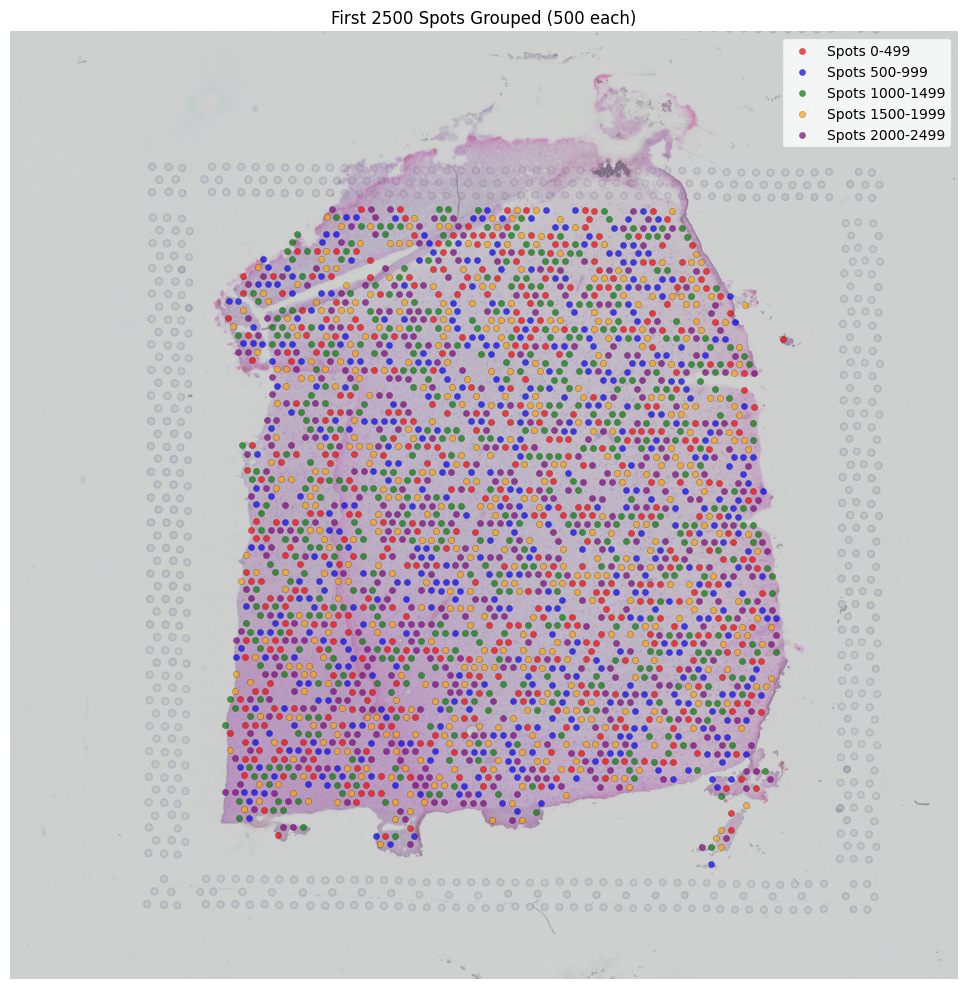

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# 路径设置
h5ad_path = "/data2/xiaoxinyu/project/embedding-cosine/DLPFC/top2000/151674/stdata.h5ad"
img_path = "/data1/xiaoxinyu/benchmark/DLPFC/process-data/train-data/151674/tissue_hires_image.png"

# 加载组织图像
img = mpimg.imread(img_path)
import cv2
height, width = img.shape[:2]
n = 6.7 # 设置图像放大倍数
img = cv2.resize(img, (int(width*n), int(height*n)), interpolation=cv2.INTER_LINEAR)

# 读取 .h5ad 文件
adata = sc.read_h5ad(h5ad_path)

# 提取前2500个 spot 的坐标
coords = adata.obsm["spatial"][:2500]
coords = coords[:, [1, 0]] 

# 设置每组大小和颜色映射
group_size = 500
group_num = 5

# 自定义颜色（你也可以替换成自己喜欢的颜色）
cmap = ['red', 'blue', 'green', 'orange', 'purple']
# cmap = plt.cm.get_cmap('tab10', group_num)

# 绘图
plt.figure(figsize=(10, 10))
# plt.imshow(img)
plt.imshow(img, alpha=0.6)  # 设置组织图像透明度

for i in range(group_num):
    start = i * group_size
    end = (i + 1) * group_size
    group_coords = coords[start:end]
    xs, ys = group_coords[:, 0], group_coords[:, 1]
    plt.scatter(xs, ys, s=20, color=cmap[i], alpha=0.7, label=f"Spots {start}-{end - 1}", edgecolors='k', linewidths=0.2)
                
plt.title("First 2500 Spots Grouped (500 each)")
plt.axis('off')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


##### 按cluster标注颜色

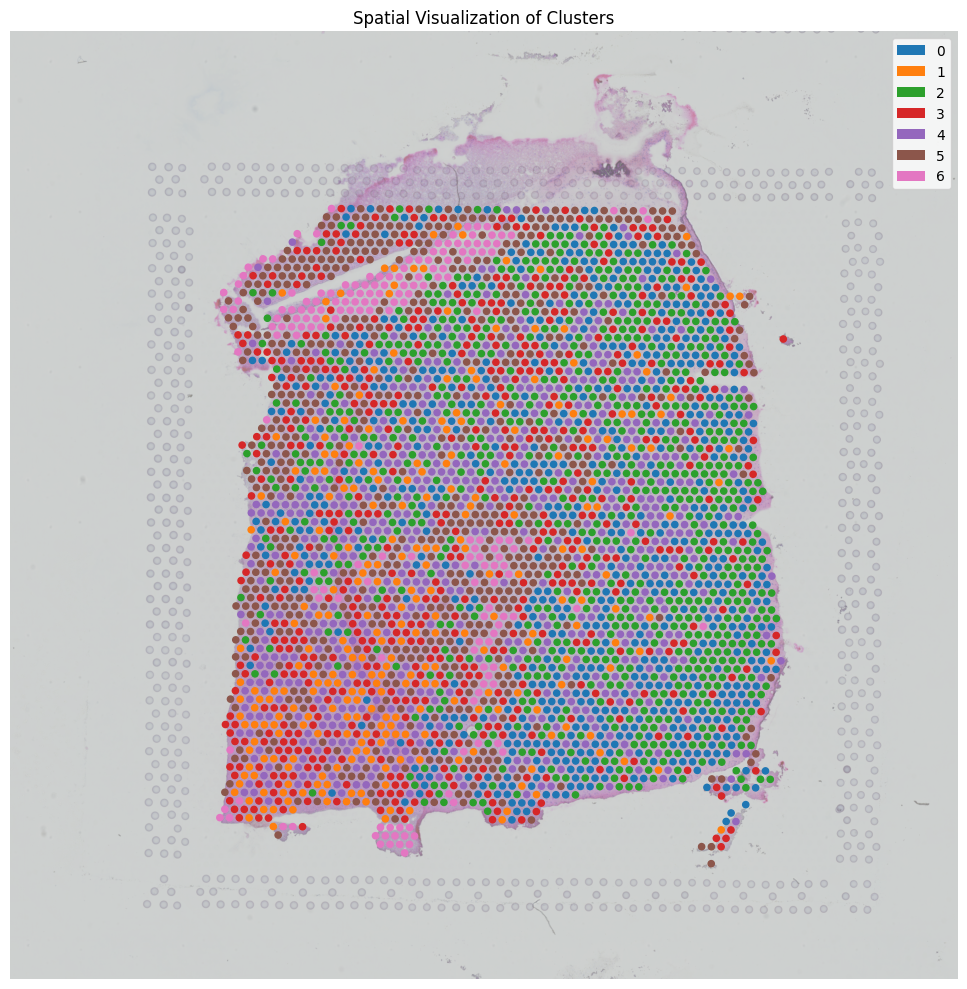

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# === 加载组织图像 ===
img_path = "/data1/xiaoxinyu/benchmark/DLPFC/process-data/train-data/151674/tissue_hires_image.png"
img = mpimg.imread(img_path)
import cv2
height, width = img.shape[:2]
n = 6.7 # 设置图像放大倍数
img = cv2.resize(img, (int(width*n), int(height*n)), interpolation=cv2.INTER_LINEAR)

# === 加载spot数据 ===
ad = anndata.read_h5ad("/data2/xiaoxinyu/project/embedding-cosine/DLPFC/top2000/151674/stdata_with_cluster.h5ad")
# 获取空间坐标和聚类标签
coords = ad.obsm['spatial']  # [3673, 2]
clusters = ad.obs['cluster']
# 获取每个spot对应颜色
cluster_categories = clusters.cat.categories
cluster_colors = ad.uns['cluster_colors']  # 与 categories 顺序对应
spot_colors = clusters.cat.codes.map(lambda x: cluster_colors[x])

# === 绘图 ===
plt.figure(figsize=(10, 10))
plt.imshow(img, alpha=0.6)

plt.scatter(coords[:, 1], coords[:, 0], 
            c=spot_colors, s=20)

plt.title("Spatial Visualization of Clusters")
plt.axis('off')
plt.tight_layout()

# 添加图例（可选）
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cluster_colors[i], label=cat) for i, cat in enumerate(cluster_categories)]
plt.legend(handles=legend_elements, loc='upper right')

plt.show()
# plt.savefig("spatial_cluster.png", dpi=300)

#### 对嵌入聚类

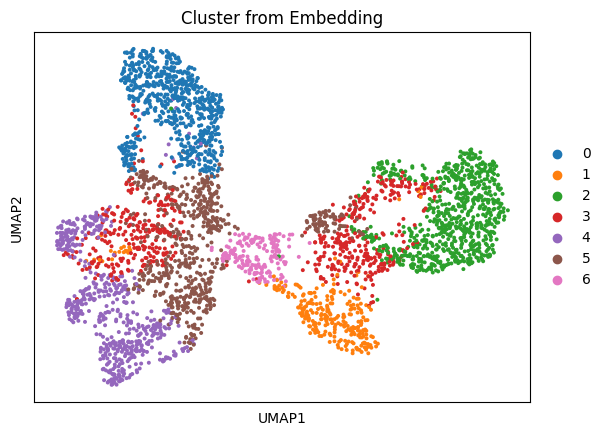

In [ ]:
import torch
import anndata
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import scanpy as sc

# 路径
h5ad_path = "/data2/xiaoxinyu/project/embedding-cosine/DLPFC/top2000/151674/stdata.h5ad"
embedding_path = "/data2/xiaoxinyu/project/embedding-cosine/DLPFC/embedding/151674/stdata.pt"

# 读取数据和嵌入
ad = anndata.read_h5ad(h5ad_path)
emb = torch.load(embedding_path)  # [3673, 512]
emb_np = emb.detach().cpu().numpy()

# 聚类
n_clusters = 7
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(emb_np)

# 添加聚类标签
ad.obs['cluster'] = pd.Categorical(cluster_labels.astype(str))

# 绘图
ad.obsm['X_emb'] = emb_np # 加入嵌入作为邻居计算用的表示
sc.pp.neighbors(ad, use_rep='X_emb', n_neighbors=15) # 计算邻居图
sc.tl.umap(ad) # 计算UMAP
sc.pl.umap(ad, color='cluster', title='Cluster from Embedding', save="_embedding_cluster.png")

# 保存
ad.write_h5ad("/data2/xiaoxinyu/project/embedding-cosine/DLPFC/top2000/151674/stdata_with_cluster.h5ad")
